In [1]:
import pandas as pd
import numpy as np

In [2]:
import pickle
df=pickle.load(open('cleaned_df.pkl','rb'))

In [3]:
df.head(1)

,text,label,text_len
0,oh gosh,Anxiety,2


In [4]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [5]:
df['label_enc'] =le.fit_transform(df['label'])
print(list(le.classes_))

['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [6]:
import pickle
pickle.dump(le,open('LabelEncoder.pkl','wb'))

In [7]:
MAX_WORDS=20000
MAX_LEN=150
EMBED_DIM=128

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Bidirectional,Dropout,GlobalAvgPool1D,Embedding,GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping


In [10]:
tokenizer=Tokenizer(num_words=MAX_WORDS,oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

In [11]:
pickle.dump(tokenizer,open('Tokenizer.pkl','wb'))

In [12]:
X=pad_sequences(tokenizer.texts_to_sequences(df['text']),maxlen=MAX_LEN,padding='post',truncating='post')
y=df['label_enc'].values# sparse categorical cross entropy now we will use @# we can use  categorical cross entropy also -> to_cateorical

In [13]:
n_classes=len(le.classes_)

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [15]:
model=Sequential([
    Embedding(input_length=MAX_LEN,input_dim=MAX_WORDS,output_dim=128),
    Bidirectional(LSTM(128,return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64,return_sequences=False)),
    Dropout(0.2),
    #GlobalMaxPooling1D(),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(n_classes,activation='softmax')    
])

c:\Users\Atharva\cs corner\ML_PROJECTS\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
model.build(input_shape=(None,MAX_LEN))

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,998,087 (11.44 MB)

 Trainable params: 2,998,087 (11.44 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
##  We have seen thet the class is imbalances o we will apply class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights=compute_class_weight(class_weight='balanced',classes=np.unique(y_train),y=y_train)

In [20]:
class_weights_dict=dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(1.9491961414790997), 1: np.float64(2.633362293657689), 2: np.float64(0.49192566745110766), 3: np.float64(0.4634202278113294), 4: np.float64(6.308012486992716), 5: np.float64(2.839344262295082), 6: np.float64(0.711335367284675)}


In [21]:
earlystoppin=EarlyStopping(patience=10,restore_best_weights=True,verbose=1)


In [22]:
history=model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.1,callbacks=earlystoppin,class_weight=class_weights_dict)

Epoch 1/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 373s 614ms/step - accuracy: 0.5063 - loss: 1.3326 - val_accuracy: 0.5985 - val_loss: 1.0333
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 366s 613ms/step - accuracy: 0.6445 - loss: 0.8400 - val_accuracy: 0.6513 - val_loss: 0.8216
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 351s 588ms/step - accuracy: 0.7048 - loss: 0.6376 - val_accuracy: 0.6897 - val_loss: 0.7655
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 455s 762ms/step - accuracy: 0.7539 - loss: 0.5122 - val_accuracy: 0.6654 - val_loss: 0.9594
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 443s 741ms/step - accuracy: 0.7802 - loss: 0.4403 - val_accuracy: 0.7038 - val_loss: 0.8434
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 383s 641ms/step - accuracy: 0.8113 - loss: 0.3681 - val_accuracy: 0.7217 - val_loss: 0.7937
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 375s 628ms/step - accuracy: 0.8440 - loss: 0.3008 - val_accuracy: 0.7262 - val_loss: 0.8079
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 365s 611ms/step - accuracy: 0.8602 -

In [23]:
y_pred=model.predict(X_test)
y_pred_str=np.argmax(y_pred,axis=1)
y_test_str=y_test 

332/332 ━━━━━━━━━━━━━━━━━━━━ 32s 92ms/step


In [24]:
print(classification_report(y_test_str,y_pred_str,target_names=le.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.77      0.78      0.77       778
             Bipolar       0.73      0.80      0.77       575
          Depression       0.69      0.36      0.47      3081
              Normal       0.91      0.89      0.90      3270
Personality disorder       0.43      0.73      0.54       240
              Stress       0.53      0.56      0.55       534
            Suicidal       0.49      0.79      0.61      2131

            accuracy                           0.68     10609
           macro avg       0.65      0.70      0.66     10609
        weighted avg       0.71      0.68      0.67     10609



In [25]:
cm=confusion_matrix(y_test_str,y_pred_str)

<Axes: >

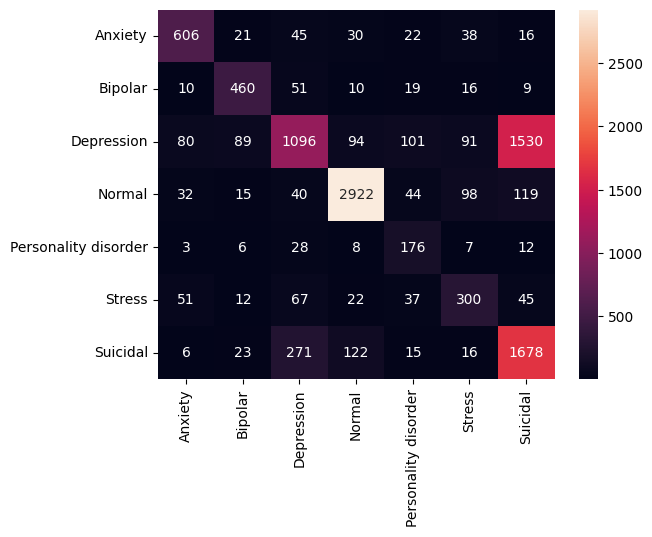

In [26]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d',xticklabels=le.classes_,yticklabels=le.classes_)

In [27]:
model.save('Bidirectional_lstm.h5')